In [1]:
# Импорт необходимых библиотек

import numpy as np
import kagglehub
import os
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:
# 1 Загрузка и распаковка датасета

!pip install kagglehub

path = kagglehub.dataset_download("vjchoudhary7/customer-segmentation-tutorial-in-python")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'customer-segmentation-tutorial-in-python' dataset.
Path to dataset files: /kaggle/input/customer-segmentation-tutorial-in-python


In [3]:
# Проверяем название датасета

files = os.listdir(path)
print(files)

['Mall_Customers.csv']


In [4]:
# Загрузка данных в DataFrame

df = pd.read_csv(os.path.join(path, "Mall_Customers.csv"))
print(df.head())
print("\nРазмерность:", df.shape)
print("\nТипы колонок:\n", df.dtypes)

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Размерность: (200, 5)

Типы колонок:
 CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object


In [5]:
# 2 Проверка данных на наличие пропусков, дубликатов, и очистка.

print("Пропуски в данных:", df.isnull().sum().sum())
print("Количество дубликатов:", df.duplicated().sum())
print("Размерность данных:", df.shape)
print("Количество наблюдений:", len(df))
print("Количество признаков:", df.shape[1])

Пропуски в данных: 0
Количество дубликатов: 0
Размерность данных: (200, 5)
Количество наблюдений: 200
Количество признаков: 5


In [19]:
# Так как пропусков, дубликатов, нет. Для наглядности добавляем пропуски в случайные ячейки вручную и обрабатываем.
df_work = df.copy()

# индексы строк, где будут пропуски
specific_indices = [7, 12, 34, 55, 99]

# Вносим пропуски во все нужные столбцы для этих строк
df_work.loc[specific_indices, ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']] = np.nan

In [20]:
# Проверяем, что пропуски появились
print("Пропуски:\n")
print(df_work.isnull().sum())

Пропуски:

CustomerID                0
Gender                    0
Age                       5
Annual Income (k$)        5
Spending Score (1-100)    5
dtype: int64


In [21]:
# Заполняем пропуски медианой.
df_work['Age'] = df_work['Age'].fillna(df_work['Age'].median())
df_work['Annual Income (k$)'] = df_work['Annual Income (k$)'].fillna(df_work['Annual Income (k$)'].median())
df_work['Spending Score (1-100)'] = df_work['Spending Score (1-100)'].fillna(df_work['Spending Score (1-100)'].median())

In [23]:
# Финальная проверка
print("Пропуски:\n")
print(df_work.isnull().sum())

Пропуски:

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [10]:
# 4 Предобработка данных. Выполнение стандартизации признаков.

# Для кластеризации используем числовые признаки
features = df_work[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

print("Матрица стандартизированных признаков:", features_scaled.shape)
print("\nСреднее после стандартизации:")
print(features_scaled.mean(axis=0))
print("\nСтандартное отклонение:")
print(features_scaled.std(axis=0))

Матрица стандартизированных признаков: (200, 3)

Среднее после стандартизации:
[-3.55271368e-17  7.10542736e-17  1.22124533e-16]

Стандартное отклонение:
[1. 1. 1.]


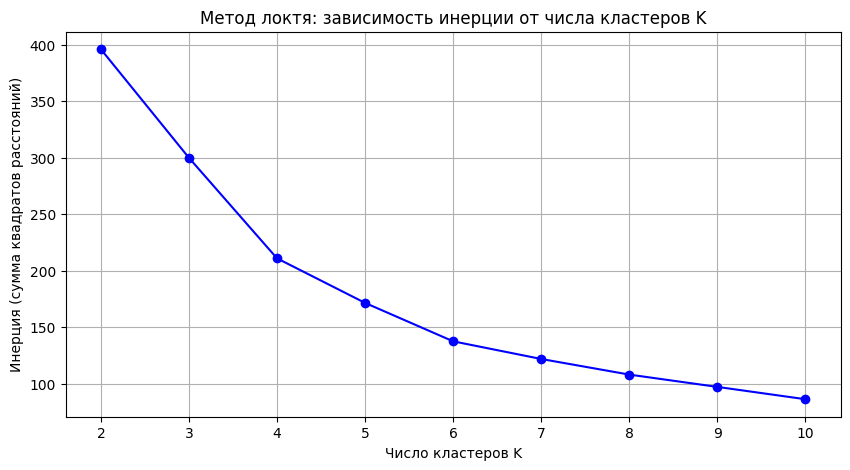

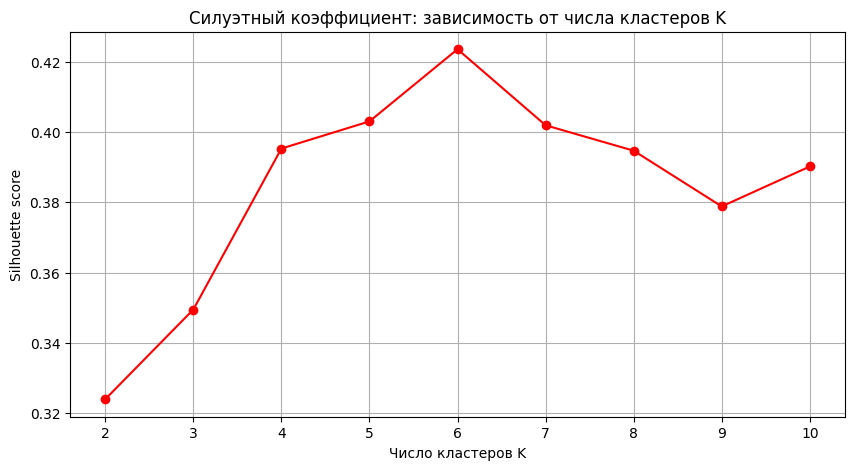

Коэффициент силуэта по K:
K=2: 0.324
K=3: 0.3495
K=4: 0.3953
K=5: 0.4031
K=6: 0.4236
K=7: 0.402
K=8: 0.3947
K=9: 0.3789
K=10: 0.3902


In [11]:
# 5 Кластеризация K-means: определение оптимального числа кластеров K

# Метод локтя (Elbow method)
# Перебираем K от 2 до 10, считаем инерцию и силуэтный коэффициент

inertia = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(features_scaled)
    inertia.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(features_scaled, kmeans.labels_))

# Строим график локтя
plt.figure(figsize=(10, 5))
plt.plot(K_range, inertia, 'bo-')
plt.title('Метод локтя: зависимость инерции от числа кластеров K')
plt.xlabel('Число кластеров K')
plt.ylabel('Инерция (сумма квадратов расстояний)')
plt.xticks(K_range)
plt.grid(True)
plt.show()

# Строим график силуэтного коэффициента
plt.figure(figsize=(10, 5))
plt.plot(K_range, silhouettes, 'ro-')
plt.title('Силуэтный коэффициент: зависимость от числа кластеров K')
plt.xlabel('Число кластеров K')
plt.ylabel('Silhouette score')
plt.xticks(K_range)
plt.grid(True)
plt.show()

print("Коэффициент силуэта по K:")
for k, s in zip(K_range, silhouettes):
    print(f"K={k}: {round(s, 4)}")

K-means обучен с K = 6

Распределение клиентов по кластерам:
Kmeans_Cluster
0    44
1    39
2    22
3    34
4    19
5    42
Name: count, dtype: int64


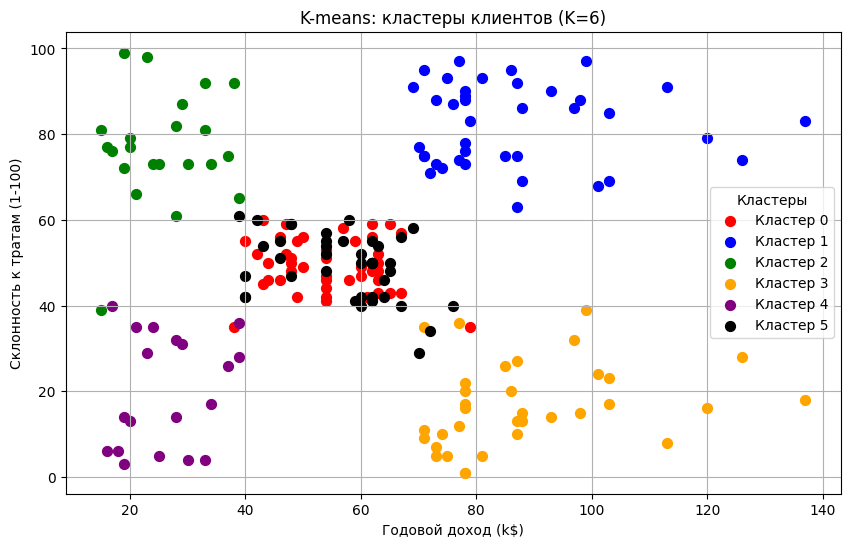

In [12]:
# Кластеризация с K-means. Выбираем k = 6.

K = 6
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
kmeans.fit(features_scaled)

df_work['Kmeans_Cluster'] = kmeans.labels_

print("K-means обучен с K =", K)
print("\nРаспределение клиентов по кластерам:")
print(df_work['Kmeans_Cluster'].value_counts().sort_index())

# Визуализация кластеров (доход vs склонность к тратам)
plt.figure(figsize=(10, 6))

colors = ['red', 'blue', 'green', 'orange','purple','black']
for cluster in range(K):
    cluster_data = df_work[df_work['Kmeans_Cluster'] == cluster]
    plt.scatter(cluster_data['Annual Income (k$)'], cluster_data['Spending Score (1-100)'],
                c=colors[cluster], s=50, label=f'Кластер {cluster}')

plt.title('K-means: кластеры клиентов (K=6)')
plt.xlabel('Годовой доход (k$)')
plt.ylabel('Склонность к тратам (1-100)')
plt.legend(title='Кластеры')
plt.grid(True)
plt.show()

In [13]:
# Кластеризация DBSCAN: подбор параметров

# Перебираем разные значения eps и min_samples
# eps - максимальное расстояние между точками, чтобы они считались соседями
# min_samples - минимальное число точек для образования кластера

eps_values = [0.3, 0.4, 0.5, 0.6, 0.8, 1.0]
min_samples_values = [5, 10, 15]

print("DBSCAN: подбор параметров (eps, min_samples)")
print("Кластеров | Шумовых точек | Параметры")
print("-" * 45)

for eps in eps_values:
    for ms in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(features_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = (labels == -1).sum()
        print(f"{n_clusters:^8} | {n_noise:^13} | eps={eps}, min_samples={ms}")

DBSCAN: подбор параметров (eps, min_samples)
Кластеров | Шумовых точек | Параметры
---------------------------------------------
   10    |      141      | eps=0.3, min_samples=5
   0     |      200      | eps=0.3, min_samples=10
   0     |      200      | eps=0.3, min_samples=15
   9     |      90       | eps=0.4, min_samples=5
   1     |      186      | eps=0.4, min_samples=10
   0     |      200      | eps=0.4, min_samples=15
   4     |      61       | eps=0.5, min_samples=5
   4     |      114      | eps=0.5, min_samples=10
   0     |      200      | eps=0.5, min_samples=15
   2     |      34       | eps=0.6, min_samples=5
   3     |      65       | eps=0.6, min_samples=10
   3     |      117      | eps=0.6, min_samples=15
   1     |       6       | eps=0.8, min_samples=5
   1     |      25       | eps=0.8, min_samples=10
   1     |      51       | eps=0.8, min_samples=15
   1     |       2       | eps=1.0, min_samples=5
   1     |       8       | eps=1.0, min_samples=10
   1     |

In [14]:
#Тут опимальным вариантом будет eps = 0.5, min_samples = 5 - Тут наименьшее количество шумовых точек -61 шумовая точка при оптимальном числе кластеров.

DBSCAN обучен: eps = 0.5 , min_samples = 5
Количество кластеров: 4
Количество шумовых точек: 61

Распределение по кластерам (-1 = шум):
DBSCAN_Cluster
-1    61
 0    17
 1    83
 2    32
 3     7
Name: count, dtype: int64


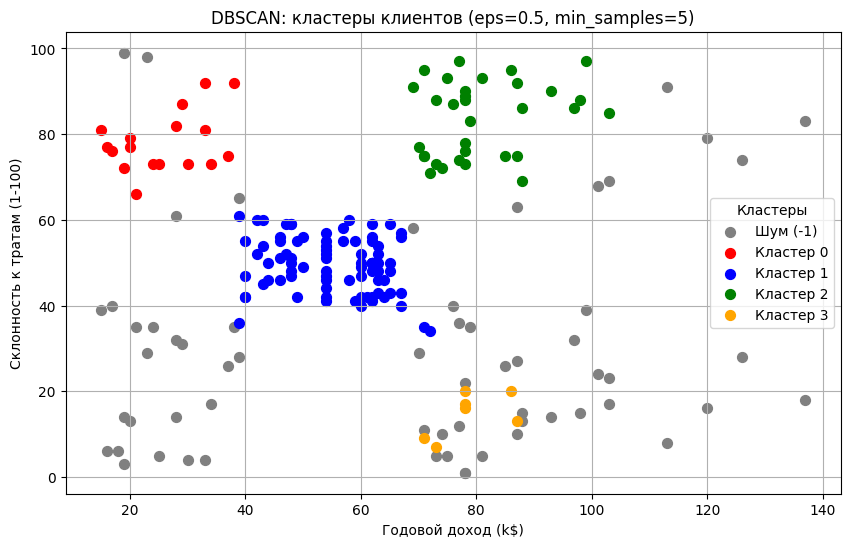

In [15]:
eps_opt = 0.5
ms_opt = 5
dbscan = DBSCAN(eps=eps_opt, min_samples=ms_opt)
db_labels = dbscan.fit_predict(features_scaled)

# Добавляем метки кластеров в датафрейм
df_work['DBSCAN_Cluster'] = db_labels

# Считаем кластеры и шум
n_db_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_db_noise = (db_labels == -1).sum()

print("DBSCAN обучен: eps =", eps_opt, ", min_samples =", ms_opt)
print("Количество кластеров:", n_db_clusters)
print("Количество шумовых точек:", n_db_noise)
print("\nРаспределение по кластерам (-1 = шум):")
print(df_work['DBSCAN_Cluster'].value_counts().sort_index())

# Визуализация кластеров DBSCAN
plt.figure(figsize=(10, 6))

colors = ['red', 'blue', 'green', 'orange']
unique_labels = sorted(set(db_labels))
for label in unique_labels:
    cluster_data = df_work[df_work['DBSCAN_Cluster'] == label]
    if label == -1:
        plt.scatter(cluster_data['Annual Income (k$)'], cluster_data['Spending Score (1-100)'],
                    c='gray', s=50, label='Шум (-1)')
    else:
        plt.scatter(cluster_data['Annual Income (k$)'], cluster_data['Spending Score (1-100)'],
                    c=colors[label], s=50, label=f'Кластер {label}')

plt.title('DBSCAN: кластеры клиентов (eps=0.5, min_samples=5)')
plt.xlabel('Годовой доход (k$)')
plt.ylabel('Склонность к тратам (1-100)')
plt.legend(title='Кластеры')
plt.grid(True)
plt.show()

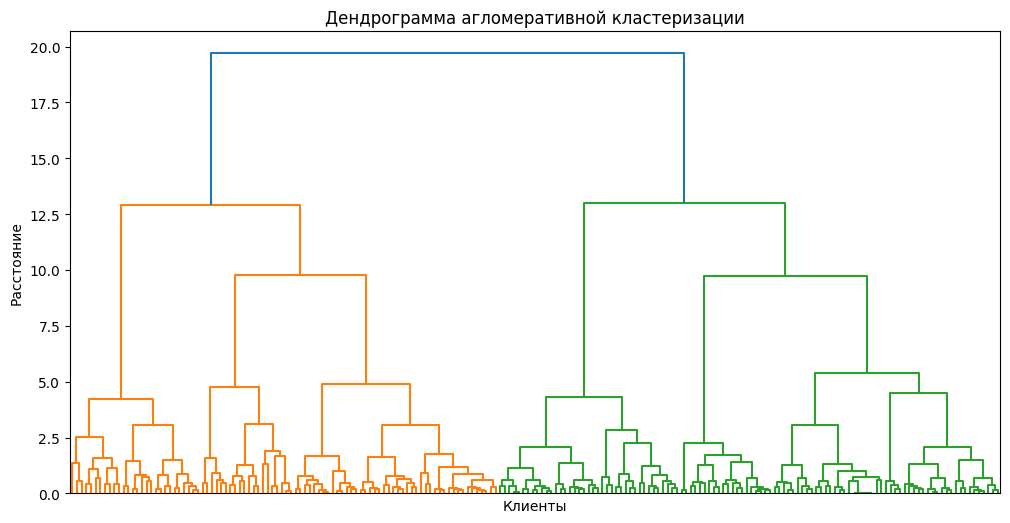

Агломеративная кластеризация обучена (K=6)

Распределение клиентов по кластерам:
Agg_Cluster
0    49
1    44
2    39
3    28
4    20
5    20
Name: count, dtype: int64


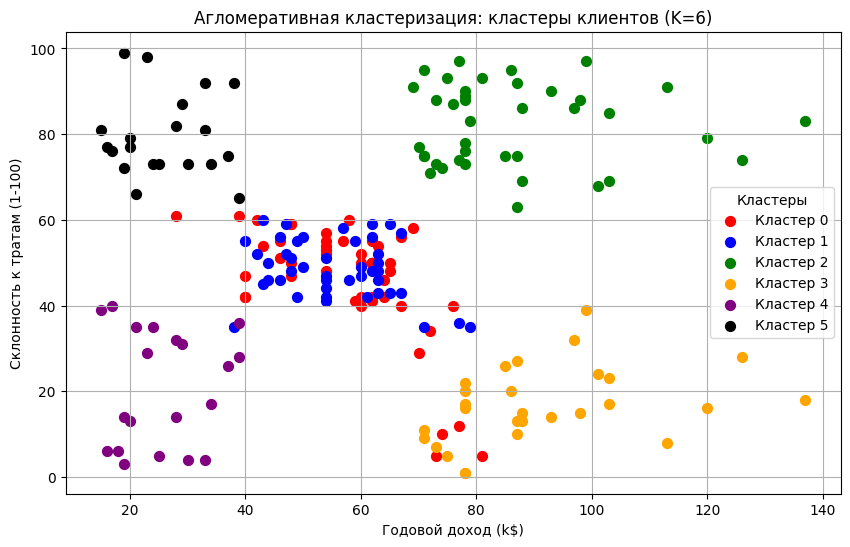

In [16]:
# Агломеративная кластеризация

# Дендрограмма (дерево объединения кластеров)
plt.figure(figsize=(12, 6))
Z = linkage(features_scaled, method='ward')
dendrogram(Z, no_labels=True)
plt.title('Дендрограмма агломеративной кластеризации')
plt.xlabel('Клиенты')
plt.ylabel('Расстояние')
plt.show()

# Обучение агломеративной кластеризации (K=6)
agg = AgglomerativeClustering(n_clusters=6)
agg_labels = agg.fit_predict(features_scaled)

# Добавляем метки в датафрейм
df_work['Agg_Cluster'] = agg_labels

print("Агломеративная кластеризация обучена (K=6)")
print("\nРаспределение клиентов по кластерам:")
print(df_work['Agg_Cluster'].value_counts().sort_index())

# Визуализация кластеров
plt.figure(figsize=(10, 6))

colors = ['red', 'blue', 'green', 'orange','purple','black']
for cluster in range(6):
    cluster_data = df_work[df_work['Agg_Cluster'] == cluster]
    plt.scatter(cluster_data['Annual Income (k$)'], cluster_data['Spending Score (1-100)'],
                c=colors[cluster], s=50, label=f'Кластер {cluster}')

plt.title('Агломеративная кластеризация: кластеры клиентов (K=6)')
plt.xlabel('Годовой доход (k$)')
plt.ylabel('Склонность к тратам (1-100)')
plt.legend(title='Кластеры')
plt.grid(True)
plt.show()

Сравнительная таблица методов кластеризации:
         Метод  Число кластеров  Шумовые точки  Silhouette score
       K-means                6              0            0.4236
        DBSCAN                4             61            0.3495
Агломеративная                6              0            0.4172


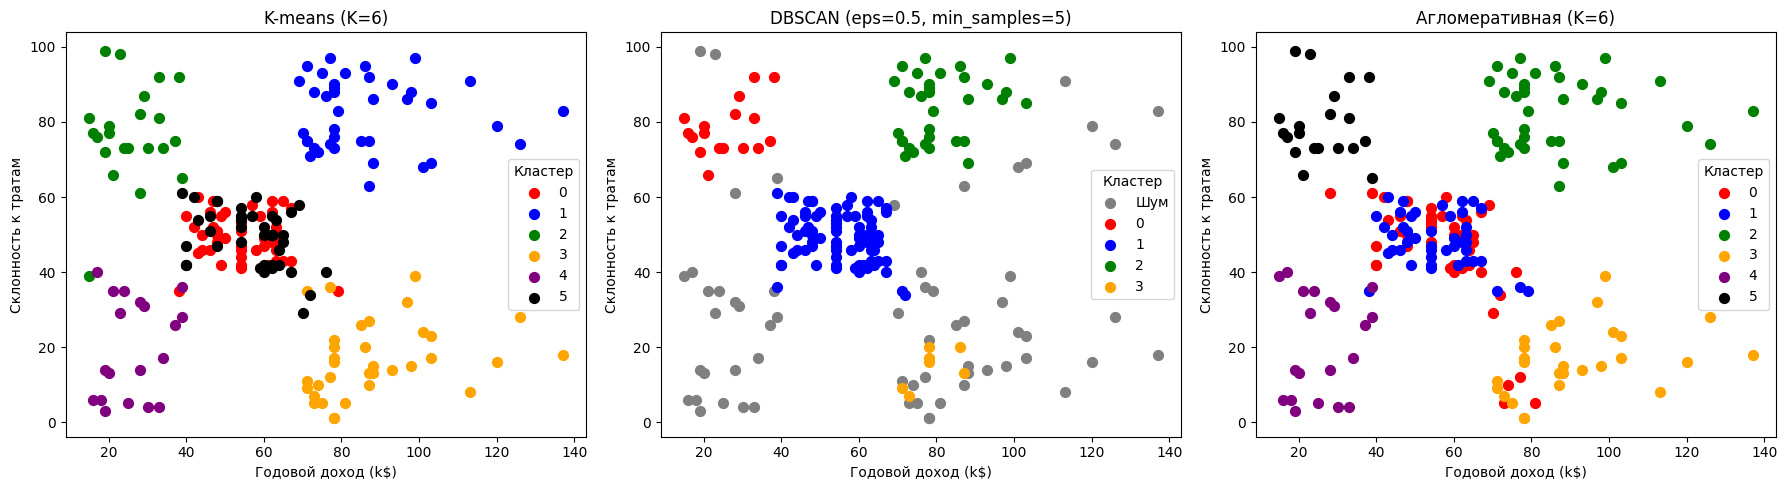

In [17]:
# 5 Сравнение результатов кластеризации

# Считаем силуэтные коэффициенты для каждого метода
# (для DBSCAN силуэт считаем без шумовых точек)

kmeans_sil = silhouette_score(features_scaled, df_work['Kmeans_Cluster'])

db_labels_clean = df_work['DBSCAN_Cluster']
db_filtered = db_labels_clean != -1
db_sil = silhouette_score(features_scaled[db_filtered], db_labels_clean[db_filtered])

agg_sil = silhouette_score(features_scaled, df_work['Agg_Cluster'])

# Сравнительная таблица
comparison = pd.DataFrame({
    'Метод': ['K-means', 'DBSCAN', 'Агломеративная'],
    'Число кластеров': [6, 4, 6],
    'Шумовые точки': [0, 61, 0],
    'Silhouette score': [round(kmeans_sil, 4), round(db_sil, 4), round(agg_sil, 4)]
})

print("Сравнительная таблица методов кластеризации:")
print(comparison.to_string(index=False))

# Визуализация: все три метода
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# K-means
colors_k = ['red', 'blue', 'green', 'orange', 'purple', 'black']
for cluster in range(6):
    cluster_data = df_work[df_work['Kmeans_Cluster'] == cluster]
    axes[0].scatter(cluster_data['Annual Income (k$)'], cluster_data['Spending Score (1-100)'],
                    c=colors_k[cluster], s=50, label=f'{cluster}')
axes[0].set_title('K-means (K=6)')
axes[0].set_xlabel('Годовой доход (k$)')
axes[0].set_ylabel('Склонность к тратам')
axes[0].legend(title='Кластер')

# DBSCAN
colors_db = ['red', 'blue', 'green', 'orange', 'purple']
unique_labels = sorted(set(df_work['DBSCAN_Cluster']))
for label in unique_labels:
    cluster_data = df_work[df_work['DBSCAN_Cluster'] == label]
    if label == -1:
        axes[1].scatter(cluster_data['Annual Income (k$)'], cluster_data['Spending Score (1-100)'],
                        c='gray', s=50, label='Шум')
    else:
        axes[1].scatter(cluster_data['Annual Income (k$)'], cluster_data['Spending Score (1-100)'],
                        c=colors_db[label], s=50, label=f'{label}')
axes[1].set_title('DBSCAN (eps=0.5, min_samples=5)')
axes[1].set_xlabel('Годовой доход (k$)')
axes[1].set_ylabel('Склонность к тратам')
axes[1].legend(title='Кластер')

# Агломеративная
colors_a = ['red', 'blue', 'green', 'orange', 'purple', 'black']
for cluster in range(6):
    cluster_data = df_work[df_work['Agg_Cluster'] == cluster]
    axes[2].scatter(cluster_data['Annual Income (k$)'], cluster_data['Spending Score (1-100)'],
                    c=colors_a[cluster], s=50, label=f'{cluster}')
axes[2].set_title('Агломеративная (K=6)')
axes[2].set_xlabel('Годовой доход (k$)')
axes[2].set_ylabel('Склонность к тратам')
axes[2].legend(title='Кластер')

plt.tight_layout()
plt.show()

In [18]:
# 7 Итоговые выводы и интерпретация кластеров ( Агломеративная)

# Профиль по кластерам (возраст, доход, траты)
print("Средние характеристики клиентов по кластерам (Агломеративная):")
cluster_profile = df_work.groupby('Agg_Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(1)
print(cluster_profile)

# Количество клиентов в каждом кластере
print("\nКоличество клиентов в каждом кластере:")
print(df_work['Agg_Cluster'].value_counts().sort_index())

Средние характеристики клиентов по кластерам (Агломеративная):
              Age  Annual Income (k$)  Spending Score (1-100)
Agg_Cluster                                                  
0            28.4                57.9                    46.2
1            56.6                55.6                    48.5
2            32.7                86.5                    82.1
3            43.9                91.3                    16.7
4            43.4                25.7                    20.8
5            24.9                26.0                    79.6

Количество клиентов в каждом кластере:
Agg_Cluster
0    49
1    44
2    39
3    28
4    20
5    20
Name: count, dtype: int64
